In [65]:
"""
Day 01 代码实战：用线性回归预测患者收缩压
医疗场景：利用患者基本体征特征预测收缩压（Systolic Blood Pressure）
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
# 设置随机种子，保证结果可复现
np.random.seed(42)
# 设置中文字体（如果运行环境支持）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial UnicodeMS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
print("✅ 环境准备完毕，开始生成模拟医疗数据...")

✅ 环境准备完毕，开始生成模拟医疗数据...


In [66]:
def generate_medical_data(n_patients=1000, random_state=42):
    """
    生成模拟患者数据集
    特征说明：
    - age: 年龄（岁），范围 25-80
    - bmi: 体质指数，范围 18-40
    - heart_rate: 静息心率（次/分钟），范围 55-110
    - fasting_glucose: 空腹血糖（mmol/L），范围 4.0-15.0
    - smoking: 是否吸烟（0=否，1=是）
    - exercise_hours: 每周运动时长（小时），范围 0-15
    - family_history: 高血压家族史（0=无，1=有）
    目标变量：
    - sbp: 收缩压（mmHg），范围约 100-200
    """
    np.random.seed(random_state)
    n = n_patients
    # ===== 生成特征 =====
    age = np.random.normal(55, 15, n).clip(25, 80)
    bmi = np.random.normal(26, 5, n).clip(18, 40)
    heart_rate = np.random.normal(75, 12, n).clip(55, 110)
    fasting_glucose = np.random.normal(5.8, 2.0,n).clip(4.0, 15.0)
    smoking = np.random.binomial(1, 0.25, n)  # 25%吸烟率
    exercise_hours = np.random.exponential(3, n).clip(0, 15)
    family_history = np.random.binomial(1, 0.35, n)  # 35%有家族史
    # ===== 生成目标变量（收缩压）=====
    # 真实的"数据生成机制"（现实中未知，我们需要用ML来学习）
    # 这里我们手动设定各特征的真实权重，加上噪声
    sbp = (
    55.0                        # 基准血压
    + 0.55 * age                # 年龄正相关
    + 1.30 * bmi                # BMI正相关
    + 0.12 * heart_rate         # 心率正相关
    + 1.80 * fasting_glucose    # 血糖正相关
    + 5.00 * smoking            # 吸烟升高血压
    - 0.80 * exercise_hours     # 运动降低血压
    + 4.50 * family_history     # 家族史风险
    + np.random.normal(0, 8, n) # 随机噪声（个体差异）
    ).clip(90, 210)
    # ===== 整合为 DataFrame =====
    df = pd.DataFrame({
        'age': age.round(1),
        'bmi': bmi.round(1),
        'heart_rate': heart_rate.round(0).astype(int),
        'fasting_glucose': fasting_glucose.round(1),
        'smoking': smoking,
        'exercise_hours': exercise_hours.round(1),
        'family_history': family_history,
        'sbp': sbp.round(1)  # 目标变量：收缩压
    })
    return df
# 生成数据
df = generate_medical_data(n_patients=1500)
print(f"数据集形状: {df.shape}")
print(f"\n前5条患者数据:")
print(df.head())
print(f"\n基本统计信息:")
print(df.describe().round(2))

数据集形状: (1500, 8)

前5条患者数据:
    age   bmi  heart_rate  fasting_glucose  smoking  exercise_hours  \
0  62.5  29.9          55              4.0        0             0.8   
1  52.9  23.2          65              4.0        0             3.8   
2  64.7  21.9          70              4.0        0             8.6   
3  77.8  26.0          98              6.6        0             2.3   
4  51.5  25.1          82              5.4        1             2.3   

   family_history    sbp  
0               1  135.6  
1               1  128.3  
2               0  130.4  
3               1  153.3  
4               0  144.9  

基本统计信息:
           age      bmi  heart_rate  fasting_glucose  smoking  exercise_hours  \
count  1500.00  1500.00     1500.00          1500.00  1500.00         1500.00   
mean     55.48    26.18       74.76             5.95     0.22            2.95   
std      13.91     4.66       11.58             1.68     0.42            2.79   
min      25.00    18.00       55.00             4.0

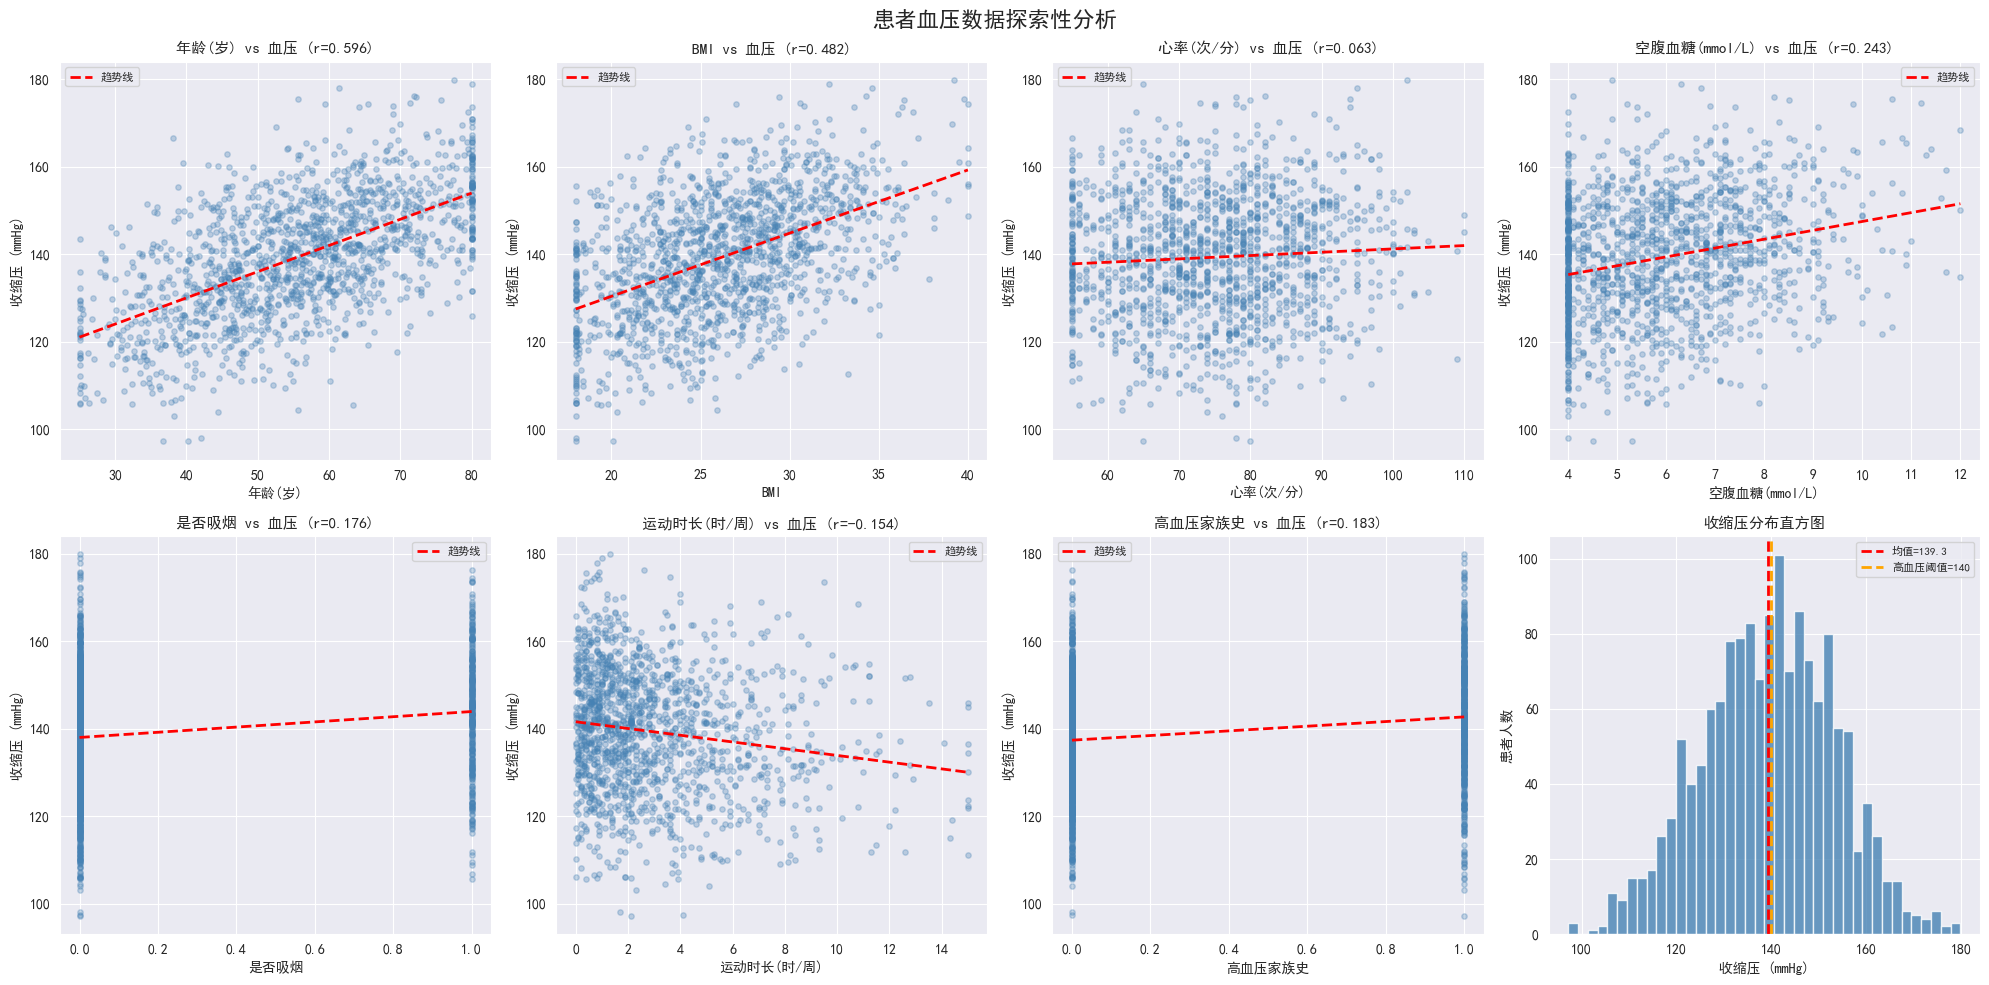


📊 各特征与收缩压的相关系数（Pearson r）：
age                 : +0.596 ↑███████████
bmi                 : +0.482 ↑█████████
fasting_glucose     : +0.243 ↑████
family_history      : +0.183 ↑███
smoking             : +0.176 ↑███
heart_rate          : +0.063 ↑█
exercise_hours      : -0.154 ↓███

📋 高血压患者比例（SBP≥140）: 49.9%


In [67]:
def exploratory_analysis(df):
    """
    探索性数据分析：在建模前，先"看"数据
    这是每个真实医疗AI项目的必经步骤
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('患者血压数据探索性分析', fontsize=16,fontweight='bold')

    features = ['age', 'bmi', 'heart_rate', 'fasting_glucose', 'smoking', 'exercise_hours', 'family_history']
    feature_names = ['年龄(岁)', 'BMI', '心率(次/分)', '空腹血糖(mmol/L)', '是否吸烟', '运动时长(时/周)', '高血压家族史']
    for i, (feat, name) in enumerate(zip(features,feature_names)):
        row, col = i // 4, i % 4
        ax = axes[row, col]

        # 散点图：特征 vs 收缩压
        ax.scatter(df[feat], df['sbp'], alpha=0.3, s=15, color='steelblue')

        # 添加趋势线
        z = np.polyfit(df[feat], df['sbp'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='趋势线')

        # 计算相关系数
        corr = df[feat].corr(df['sbp'])
        ax.set_xlabel(name, fontsize=10)
        ax.set_ylabel('收缩压 (mmHg)', fontsize=10)
        ax.set_title(f'{name} vs 血压 (r={corr:.3f})', fontsize=11)
        ax.legend(fontsize=8)

    # 第8个子图：目标变量分布
    ax = axes[1, 3]
    ax.hist(df['sbp'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df['sbp'].mean(), color='red', linestyle='--', linewidth=2, label=f'均值={df["sbp"].mean():.1f}')
    ax.axvline(140, color='orange', linestyle='--', linewidth=2, label='高血压阈值=140')
    ax.set_xlabel('收缩压 (mmHg)', fontsize=10)
    ax.set_ylabel('患者人数', fontsize=10)
    ax.set_title('收缩压分布直方图', fontsize=11)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('day01_eda.png', dpi=150, bbox_inches='tight')
    plt.show()
    # 打印相关系数（重要洞察）
    print("\n📊 各特征与收缩压的相关系数（Pearson r）：")
    print("="*45)
    corr_matrix = df.corr()['sbp'].drop('sbp').sort_values(ascending=False)
    for feat, corr in corr_matrix.items():
        bar = '█' * int(abs(corr) * 20)
        direction = '↑' if corr > 0 else '↓'
        print(f"{feat:20s}: {corr:+.3f} {direction}{bar}")
    # 高血压患者比例
    hypertension_rate = (df['sbp'] >= 140).mean()
    print(f"\n📋 高血压患者比例（SBP≥140）: {hypertension_rate:.1%}")
exploratory_analysis(df)

In [68]:
def prepare_data(df, test_size=0.2, val_size=0.1):
    """
    数据准备：分割数据集 + 特征标准化
    注意：StandardScaler 必须只在训练集上 fit！
    然后用训练集的统计量 transform 验证集和测试集。
    这模拟了真实部署：我们不知道未来患者的数据分布。
    """
    # 特征列和目标列
    feature_cols = ['age', 'bmi', 'heart_rate', 'fasting_glucose', 'smoking', 'exercise_hours', 'family_history']
    target_col = 'sbp'
    X = df[feature_cols].values
    y = df[target_col].values
    # Step 1: 先分出测试集（永远不动它！）
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42,
    )
    # Step 2: 再从剩余数据中分出验证集
    # val_size 相对于原始数据的比例
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=42
    )
    # Step 3: 特征标准化（Z-score）
    # 关键：只在训练集上 fit！
    # fit_transform和transform的区别
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)      #fit + transform
    X_val_scaled = scaler.transform(X_val)              # only transform！
    X_test_scaled = scaler.transform(X_test)            # only transform！
    print(f"📊 数据集分割结果：")
    print(f"  训练集: {X_train.shape[0]} 样本 ({X_train.shape[0]/len(df):.0%})")
    print(f"  验证集: {X_val.shape[0]} 样本 ({X_val.shape[0]/len(df):.0%})")
    print(f"  测试集: {X_test.shape[0]} 样本 ({X_test.shape[0]/len(df):.0%})")
    print(f"\n🔧 标准化后的训练集统计（应接近均值=0，标准差=1）：")
    print(f"  均值: {X_train_scaled.mean(axis=0).round(3)}")
    print(f"  标准差: {X_train_scaled.std(axis=0).round(3)}")
    print(f"\n📐 Scaler 学到的均值（来自训练集）：")
    for feat, mean, std in zip(feature_cols, scaler.mean_,  scaler.scale_):
        print(f"  {feat:20s}: μ={mean:.2f}, σ={std:.2f}")
    return (X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, scaler, feature_cols)
data = prepare_data(df)
X_train, X_val, X_test, y_train, y_val, y_test, scaler,feature_cols = data

📊 数据集分割结果：
  训练集: 1050 样本 (70%)
  验证集: 150 样本 (10%)
  测试集: 300 样本 (20%)

🔧 标准化后的训练集统计（应接近均值=0，标准差=1）：
  均值: [ 0. -0. -0. -0. -0.  0.  0.]
  标准差: [1. 1. 1. 1. 1. 1. 1.]

📐 Scaler 学到的均值（来自训练集）：
  age                 : μ=55.67, σ=13.93
  bmi                 : μ=26.17, σ=4.51
  heart_rate          : μ=75.12, σ=11.78
  fasting_glucose     : μ=5.90, σ=1.64
  smoking             : μ=0.22, σ=0.42
  exercise_hours      : μ=2.98, σ=2.73
  family_history      : μ=0.37, σ=0.48


In [69]:
def train_linear_regression(X_train, y_train, X_val, y_val, feature_cols):
    """
    训练线性回归模型，分析权重，并在验证集上评估
    """
    # ===== 实例化并训练模型 =====
    model = LinearRegression()
    model.fit(X_train, y_train)
    # 内部发生了什么？
    # sklearn 求解正规方程：θ* = (X^T X)^{-1} X^T y
    print("=" * 55)
    print("📈 线性回归模型训练完成！")
    print("=" * 55)
    # ===== 查看学到的参数 =====
    print(f"\n🎯 模型学到的参数（截距）：θ₀ =  {model.intercept_:.4f}")
    print(f"\n🎯 模型学到的权重（标准化后的特征）：")
    print("-" * 45)
    # 按权重绝对值排序，看哪个特征最重要
    coef_df = pd.DataFrame({
        '特征': feature_cols,
        '权重θ': model.coef_,
        '权重绝对值': np.abs(model.coef_)
    }).sort_values('权重绝对值', ascending=False)
    for _, row in coef_df.iterrows():
        bar_len = int(row['权重绝对值'] / coef_df['权重绝对值'].max() * 20)
        bar = '█' * bar_len
        direction = '+' if row['权重θ'] > 0 else '-'
        print(f"  {row['特征']:20s}: {row['权重θ']:+8.4f}{direction}{bar}")
    # ===== 在验证集上评估 =====
    y_val_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_val_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    print(f"\n📊 验证集评估结果：")
    print(f"  MSE  (均方误差)    : {mse:.2f} mmHg²")
    print(f"  RMSE (均方根误差)  : {rmse:.2f} mmHg")
    print(f"  MAE  (平均绝对误差): {mae:.2f} mmHg")
    print(f"  R²   (决定系数)   : {r2:.4f}")
    if r2 > 0.8:
        print(f"  ✅ 模型质量：优秀（解释了{r2:.0%}的血压方差）")
    elif r2 > 0.6:
        print(f"  ⚠  模型质量：良好（解释了{r2:.0%}的血压方差）")
    else:
        print(f"  ❌ 模型质量：需要改进（解释了{r2:.0%}的血压方差）")
    return model, coef_df
model, coef_df = train_linear_regression(
    X_train, y_train, X_val, y_val, feature_cols
)
'''
类别占比不平衡，高血压患者比例过多

'''

📈 线性回归模型训练完成！

🎯 模型学到的参数（截距）：θ₀ =  139.3858

🎯 模型学到的权重（标准化后的特征）：
---------------------------------------------
  age                 :  +7.8326+████████████████████
  bmi                 :  +6.4323+████████████████
  fasting_glucose     :  +2.8240+███████
  smoking             :  +2.4379+██████
  exercise_hours      :  -2.2969-█████
  family_history      :  +1.9953+█████
  heart_rate          :  +1.2224+███

📊 验证集评估结果：
  MSE  (均方误差)    : 47.41 mmHg²
  RMSE (均方根误差)  : 6.89 mmHg
  MAE  (平均绝对误差): 5.36 mmHg
  R²   (决定系数)   : 0.7507
  ⚠  模型质量：良好（解释了75%的血压方差）


'\n类别占比不平衡，高血压患者比例过多\n\n'

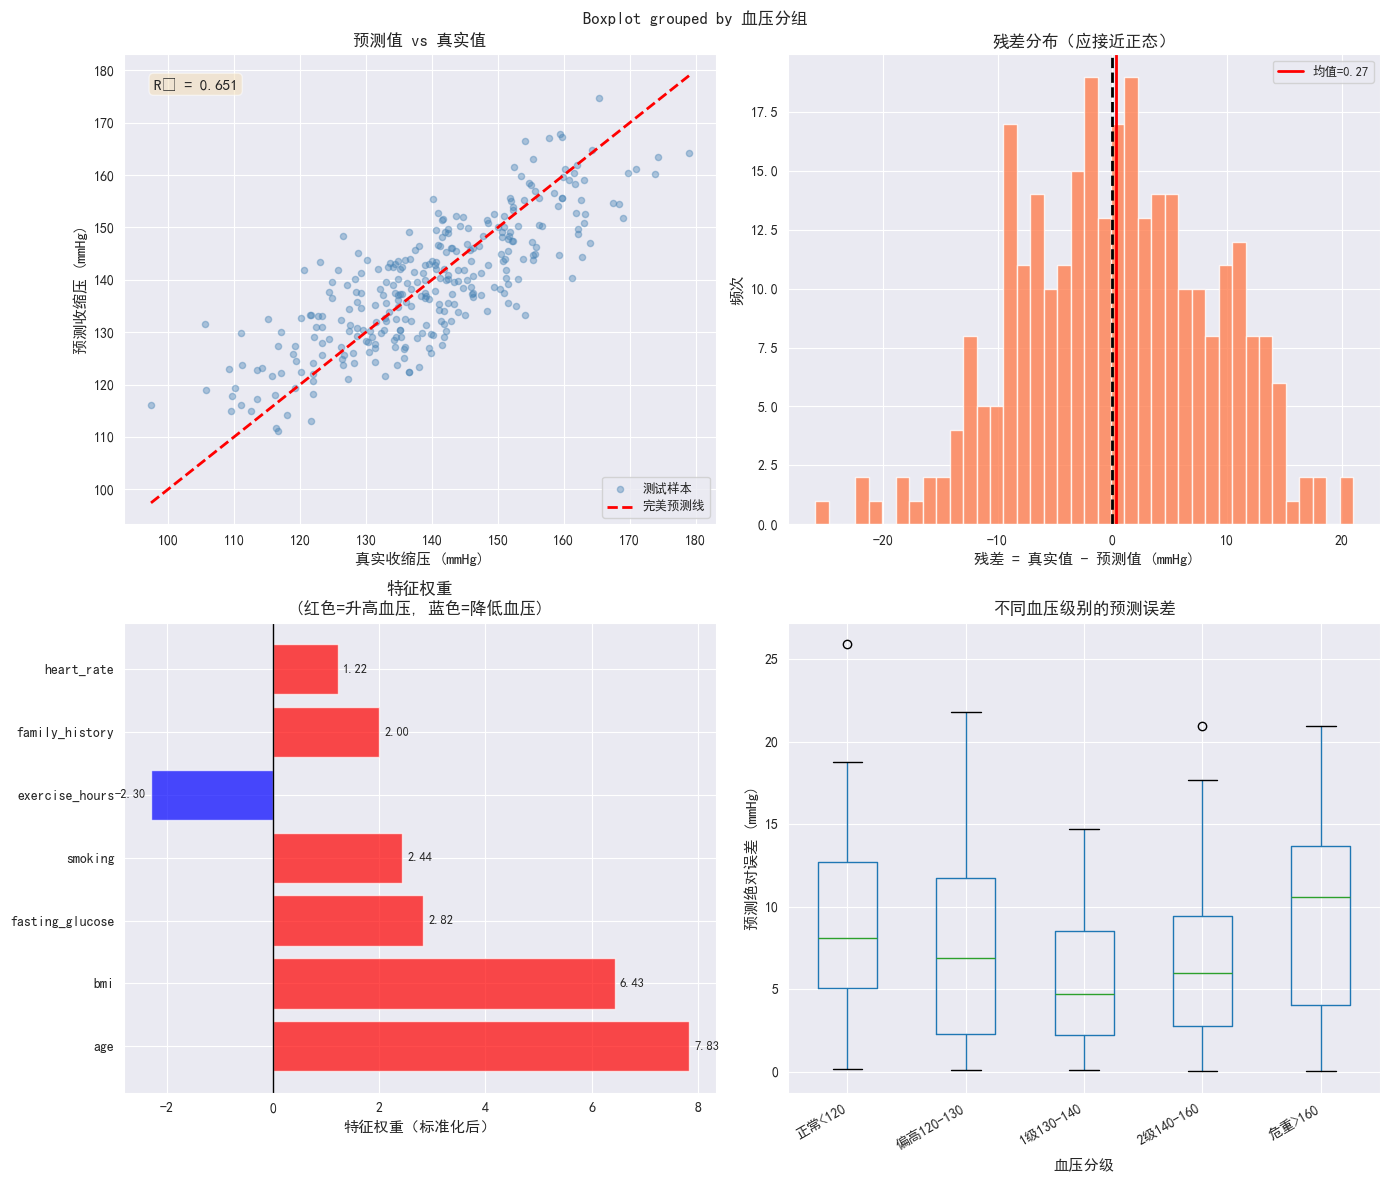

In [70]:
def visualize_model_performance(model, X_test, y_test, coef_df, feature_cols):
    """
    全面可视化模型性能——这在医疗 AI 汇报中必不可少
    """
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'线性回归模型性能报告\n(R²={r2:.3f}, RMSE={rmse:.1f} mmHg, MAE={mae:.1f} mmHg)', fontsize=14, fontweight='bold')
    # ─── 图1：预测值 vs 真实值散点图 ───
    ax1 = axes[0, 0]
    ax1.scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue', label='测试样本')
    perfect_line = [y_test.min(), y_test.max()]
    ax1.plot(perfect_line, perfect_line, 'r--', linewidth=2, label='完美预测线')
    ax1.set_xlabel('真实收缩压 (mmHg)', fontsize=11)
    ax1.set_ylabel('预测收缩压 (mmHg)', fontsize=11)
    ax1.set_title('预测值 vs 真实值', fontsize=12)
    ax1.legend(fontsize=9)
    ax1.text(0.05, 0.95, f'R² = {r2:.3f}',
            transform=ax1.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat',
            alpha=0.5))
    # ─── 图2：残差分布 ───
    ax2 = axes[0, 1]
    residuals = y_test - y_pred
    ax2.hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
    ax2.axvline(0, color='black', linestyle='--', linewidth=2)
    ax2.axvline(residuals.mean(), color='red', linestyle='-', linewidth=2,
    label=f'均值={residuals.mean():.2f}')
    ax2.set_xlabel('残差 = 真实值 - 预测值 (mmHg)', fontsize=11)
    ax2.set_ylabel('频次', fontsize=11)
    ax2.set_title('残差分布（应接近正态）', fontsize=12)
    ax2.legend(fontsize=9)
    # ─── 图3：特征重要性（权重绝对值） ───
    ax3 = axes[1, 0]
    colors = ['red' if c > 0 else 'blue' for c in coef_df['权重θ']]
    bars = ax3.barh(coef_df['特征'], coef_df['权重θ'], color=colors, alpha=0.7)
    ax3.axvline(0, color='black', linewidth=1)
    ax3.set_xlabel('特征权重（标准化后）', fontsize=11)
    ax3.set_title('特征权重\n(红色=升高血压, 蓝色=降低血压)', fontsize=12)
    # 在条形上标注数值
    for bar, val in zip(bars, coef_df['权重θ']):
        ax3.text(val +
                 (0.1 if val > 0 else -0.1),
                 bar.get_y()
                 + bar.get_height()/2,
                 f'{val:.2f}', ha='left' if val > 0 else  'right',
                va='center', fontsize=9)
    # ─── 图4：预测误差在不同血压范围的分布 ───
    ax4 = axes[1, 1]
    bp_bins = pd.cut(y_test, bins=[90, 120, 130, 140, 160, 210],
                     labels=['正常<120', '偏高120-130', '1级130-140', '2级140-160', '危重>160'])
    error_by_group = pd.DataFrame({'真实值': y_test, '绝对误差': np.abs(residuals), '血压分组': bp_bins})
    error_by_group.boxplot(column='绝对误差', by='血压分组',ax=ax4)
    ax4.set_xlabel('血压分级', fontsize=11)
    ax4.set_ylabel('预测绝对误差 (mmHg)', fontsize=11)
    ax4.set_title('不同血压级别的预测误差', fontsize=12)
    plt.sca(ax4)
    plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig('day01_model_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_model_performance(model, X_test, y_test, coef_df, feature_cols)